In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/electricity_bill_dataset.csv")

df.head()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


## Distribution of Electricity Bill

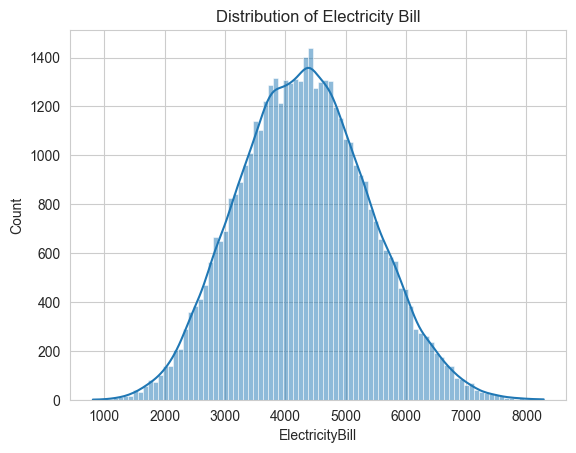

In [9]:
plt.figure()
sns.histplot(df['ElectricityBill'], kde=True)
plt.title("Distribution of Electricity Bill")
plt.show()

## Appliance Usage Distribution

<Figure size 640x480 with 0 Axes>

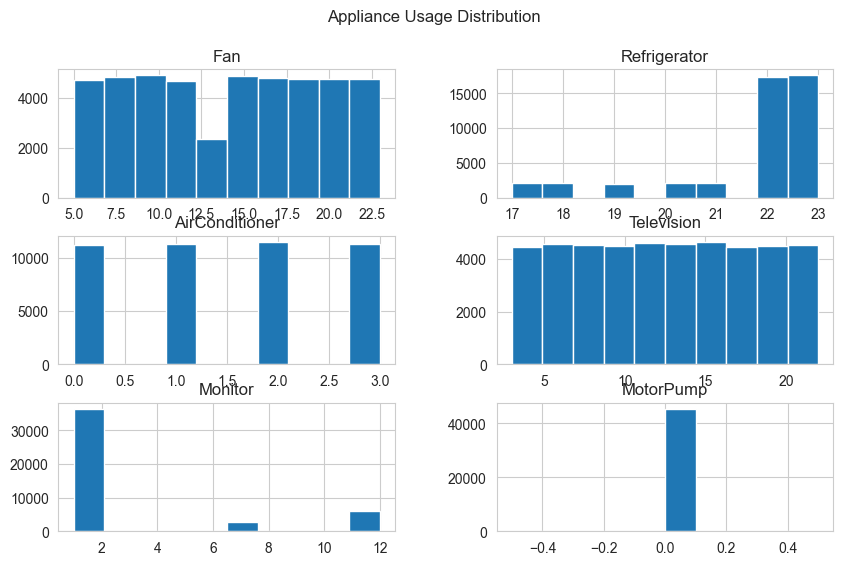

In [10]:
plt.figure()
df[['Fan','Refrigerator','AirConditioner','Television','Monitor','MotorPump']].hist(figsize=(10,6))
plt.suptitle("Appliance Usage Distribution")
plt.show()

## Correlation Heatmap

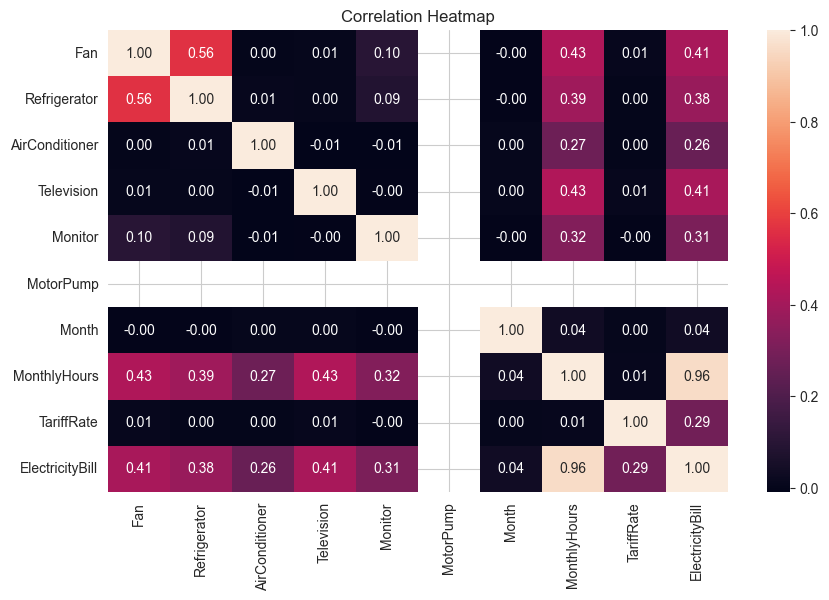

In [11]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## AC Usage vs Bill (KEY INSIGHT)

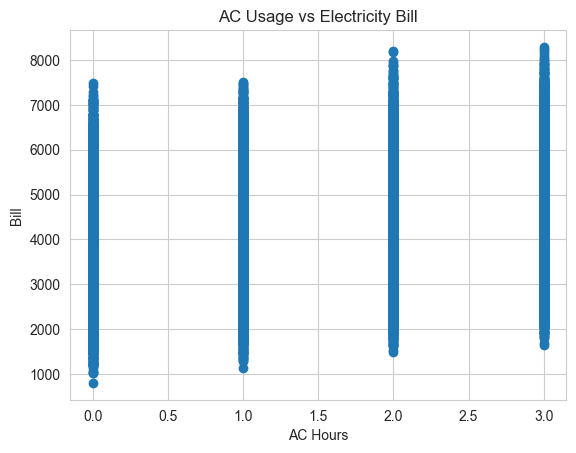

In [12]:
plt.figure()
plt.scatter(df['AirConditioner'], df['ElectricityBill'])
plt.title("AC Usage vs Electricity Bill")
plt.xlabel("AC Hours")
plt.ylabel("Bill")
plt.show()

## Boxplot for Outlier

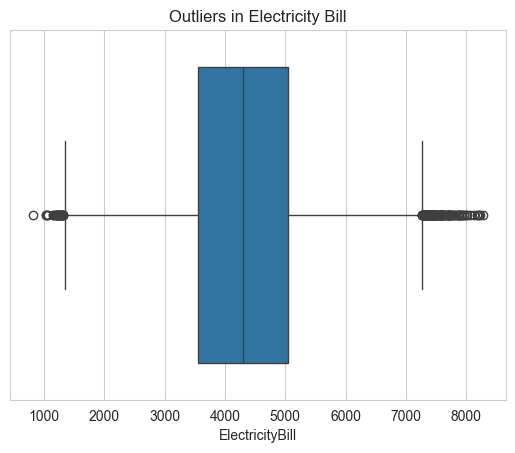

In [13]:
plt.figure()
sns.boxplot(x=df['ElectricityBill'])
plt.title("Outliers in Electricity Bill")
plt.show()

## Month vs Bill

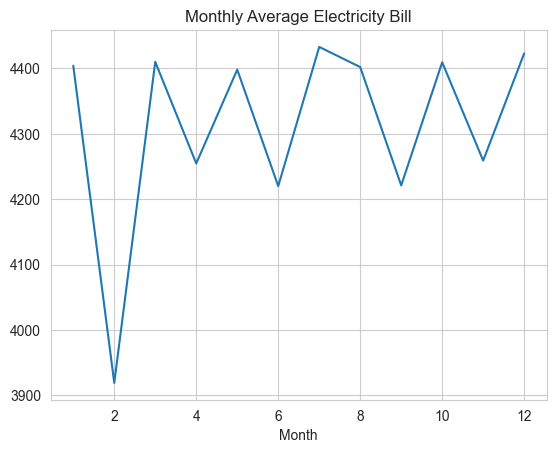

In [15]:
plt.figure()
df.groupby('Month')['ElectricityBill'].mean().plot()
plt.title("Monthly Average Electricity Bill")
plt.show()

## City-wise Average Bill

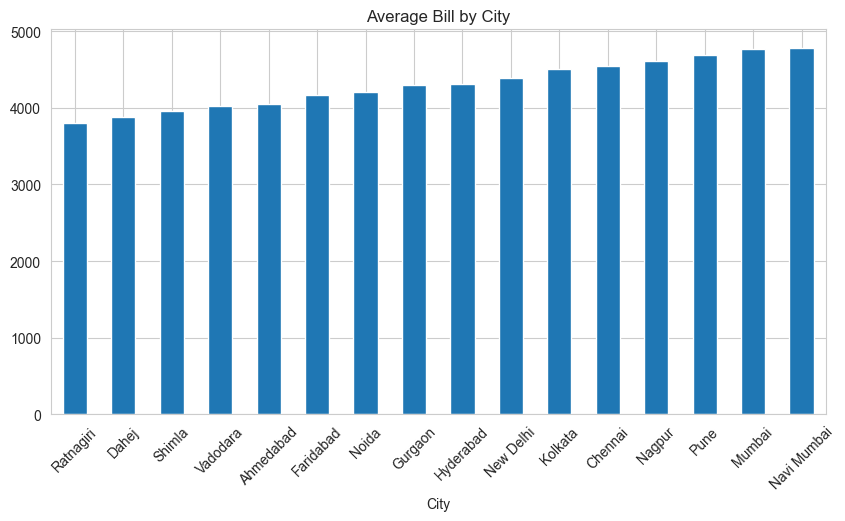

In [16]:
plt.figure(figsize=(10,5))
df.groupby('City')['ElectricityBill'].mean().sort_values().plot(kind='bar')
plt.title("Average Bill by City")
plt.xticks(rotation=45)
plt.show()

## Total Usage vs Bill (IMPORTANT)

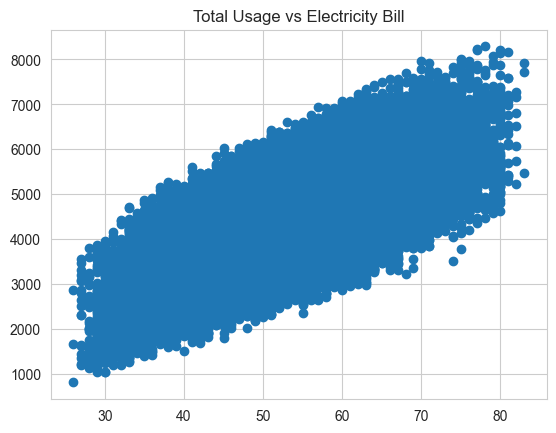

In [17]:
df['total_usage'] = df[['Fan','Refrigerator','AirConditioner','Television','Monitor','MotorPump']].sum(axis=1)

plt.figure()
plt.scatter(df['total_usage'], df['ElectricityBill'])
plt.title("Total Usage vs Electricity Bill")
plt.show()